# FRF-MLP — Kết hợp Perceptron đa lớp với logic mờ trong phát hiện ngôn từ công kích tiếng Việt

**Đồ án cuối kỳ · Học máy nâng cao**

- **Nhóm tác giả** — ĐH Công nghệ Kỹ thuật TP.HCM:
  - **Trưởng nhóm:** Nguyễn Phương Anh Tú (2611328)
  - Thành viên: Đinh Hữu Quang Anh (2611301)
  - Thành viên: Phạm Hiền Nhân (2611316)
- Bộ dữ liệu: **ViHSD** (33.398 bình luận mạng xã hội tiếng Việt, gán nhãn CLEAN / OFFENSIVE / HATE)
- Mô hình đề xuất: **FRF-MLP** (Fuzzy Rule-Fused MLP) — MLP kết hợp hệ luật mờ Mamdani ở 2 mức (đặc trưng + quyết định)

> **Mục đích notebook:** tái lập toàn bộ pipeline nghiên cứu dưới dạng cell chạy được, giải thích *từng bước*
> *vì sao làm vậy* — để giám khảo có thể "bắt giải" từng con số và đánh giá độ tin cậy. Notebook này đồng hành
> cùng báo cáo `report/paper.tex`; mã nguồn chính trong `fuzzy.py`, `train.py`, `figures.py`.

**Kết quả tóm tắt (test ViHSD):** accuracy **84,33%**, macro-F1 **63,00%** (+2,05 so với MLP thuần;
vượt Text-CNN 61,11 / GRU 60,47 / m-BERT cased 62,69 về macro-F1) — chỉ ~10,3 triệu tham số, huấn luyện vài phút CPU.

## Mục lục

1. Giới thiệu & động lực
2. Công trình liên quan
3. Phương pháp đề xuất (4 bước)
   - 3.1 Dữ liệu ViHSD & EDA
   - 3.2 Tiền xử lý
   - 3.3 Biểu diễn TF-IDF hai mức
   - 3.4 Lexicon log-odds (Dirichlet)
   - 3.5 Ba biến ngôn ngữ S, D, T
   - 3.6 Hàm thành viên + 7 luật Mamdani
   - 3.7 Kiến trúc MLP & kết hợp 2 mức
4. Thực nghiệm
   - 4.1 Baseline softmax
   - 4.2 MLP thuần
   - 4.3 FRF-MLP (đề xuất)
   - 4.4 Quét λ fusion quyết định
   - 4.5 Bảng so sánh đầy đủ + ablation
   - 4.6 Phân tích nhầm lẫn
5. Suy diễn trên 1 câu (truy vết)
6. Kết luận, hạn chế, hướng phát triển
7. Tài liệu tham khảo

## 1. Giới thiệu & động lực

Bình luận công kích/thù ghét lan truyền nhanh trên mạng xã hội Việt Nam. Theo hệ nhãn ViHSD:
- **OFFENSIVE** — nội dung tục tĩu/xúc phạm *không* hướng rõ tới một mục tiêu cụ thể.
- **HATE** — quấy rối/lăng mạ/tấn công *trực tiếp* vào một cá nhân/nhóm xác định.

Đây là lõi của các hệ kiểm duyệt nội dung tự động. Ba hướng tiếp cận hiện nay:

| Nhóm | Ưu điểm | Nhược điểm |
|---|---|---|
| Hệ luật/từ điển thủ công | diễn giải được | độ phủ thấp trước teencode biến đổi |
| Học máy/MLP trên TF-IDF | hiệu năng khá | **hộp đen**, khó giải thích |
| Transformer (BERT/PhoBERT) | hiệu năng cao | nặng (~178M tham số), cần GPU, **không diễn giải** |

**Động lực cốt lõi:** ranh giới CLEAN/OFFENSIVE/HATE vốn *mờ* — hệ số đồng thuận kappa giữa người gán nhãn
ViHSD chỉ **0,52**. Do đó biểu diễn "mức công kích" bằng *độ thuộc liên tục* (logic mờ) tự nhiên hơn nhãn cứng.

**Ý tưởng FRF-MLP:** kết hợp **cả hai** — MLP học thống kê từ TF-IDF (kênh thống kê) + hệ luật mờ Mamdani
mã hoá tri thức ngôn ngữ (kênh tri thức). Kết hợp ở **2 mức**: nối đặc trưng mờ vào đầu vào MLP (mức đặc trưng)
và cộng có trọng số phân phối mờ với xác suất MLP (mức quyết định).

**Đóng góp:**
1. Quy trình xây dựng thành phần mờ **hoàn toàn tự động từ dữ liệu** (không từ điển thủ công) cho tiếng Việt.
2. Cơ chế kết hợp **hai mức đặc trưng–quyết định** giữa hệ mờ và MLP.
3. Thực nghiệm đầy đủ trên ViHSD + ablation chứng minh mỗi mức đều có đóng góp (+2,05 macro-F1).

## 2. Công trình liên quan

- **Phát hiện ngôn từ công kích:** Davidson et al. [2] (25k tweet, 3 nhãn — khó chính là phân biệt HATE vs OFFENSIVE);
  VLSP-HSD 2019 [3] cho tiếng Việt; **ViHSD** [1] (Luu et al.) — 33.400 bình luận, baseline Text-CNN 86,69%/61,11,
  GRU 85,41%/60,47, m-BERT cased 86,88%/62,69 (accuracy/macro-F1).
- **Logic mờ trong văn bản:** Zadeh [7] (tập mờ); Wang–Mendel [8] (sinh luật từ dữ liệu); Jang [9] (ANFIS — học tham số);
  Vashishtha–Susan [11] (9 luật mờ + từ điển cảm xúc, không huấn luyện — diễn giải được nhưng yếu).
- **Kết hợp nơ-ron–mờ:** Deng et al. [10] (FDNN — hợp nhất phân cấp). Khác biệt của FRF-MLP: chỉ mờ hóa **3 biến
  ngôn ngữ mức văn bản** (không mờ hóa cả 40.000 chiều TF-IDF), giữ sức mạnh thống kê của MLP, và kết hợp **cả 2 mức**.

> **Khoảng trống:** theo khảo sát, chưa có công trình tích hợp hệ luật mờ *học tự động từ dữ liệu* vào MLP cho
> phát hiện ngôn từ công kích tiếng Việt. Nghiên cứu này lấp khoảng trống đó.

## 3. Phương pháp đề xuất

Quy trình 4 bước: **(B1)** tiền xử lý + TF-IDF → **(B2)** lexicon log-odds + biến S/D/T → **(B3)** suy diễn mờ Mamdani
→ **(B4)** MLP + kết hợp 2 mức. Toàn bộ tái lập dưới đây.

### Thiết lập môi trường

In [1]:
import sys, time, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch, torch.nn as nn
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix)

# matplotlib hiển thị trong notebook + font hỗ trợ dấu tiếng Việt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10, 'figure.dpi': 110})

warnings.filterwarnings('ignore')

# import mã nguồn chính của đồ án — tự tìm thư mục mã nguồn (notebook nằm cùng thư mục mã nguồn)
import os
PROJ = next(p for p in [Path('.'), Path('..'), Path('../Nhom_8-Tu_Nhan_Anh')]
            if (p / 'train.py').exists()).resolve()
os.chdir(PROJ); sys.path.insert(0, str(PROJ))
print('Thư mục mã nguồn:', PROJ)
from fuzzy import (normalize, tokenize, build_lexicon, CrispExtractor,
                   memberships, fuzzy_inference, fuzzy_features, _trap, RULES)
from train import load_data, build_features, train_torch, FRFMLP, report, SEED, LABELS

torch.manual_seed(SEED); np.random.seed(SEED); torch.set_num_threads(16)
print(f"torch {torch.__version__} | device CPU | seed {SEED}")
print("LABELS:", LABELS)

Thư mục mã nguồn: /home/alexdev/Projects/learning-master-ute/ml_ad/Nhom_8-Tu_Nhan_Anh
torch 2.13.0+cpu | device CPU | seed 42
LABELS: ['CLEAN', 'OFFENSIVE', 'HATE']


### 3.1 Dữ liệu ViHSD & EDA

ViHSD [1] — bộ chuẩn lớn nhất cho bài toán — 33.398 bình luận Facebook/YouTube, chia sẵn **train/dev/test = 7/1/2**.
Giữ nguyên phép chia gốc của tác giả để kết quả so sánh trực tiếp với các nghiên cứu đã công bố.

In [2]:
parts = load_data()
for s in ['train','dev','test']:
    txt, y = parts[s]
    counts = np.bincount(y, minlength=3)
    print(f"{s:5s}: {len(txt):6d} mẫu  |  CLEAN={counts[0]} OFFENSIVE={counts[1]} HATE={counts[2]}")

train:  24046 mẫu  |  CLEAN=19885 OFFENSIVE=1605 HATE=2556
dev  :   2672 mẫu  |  CLEAN=2190 OFFENSIVE=212 HATE=270
test :   6680 mẫu  |  CLEAN=5548 OFFENSIVE=444 HATE=688


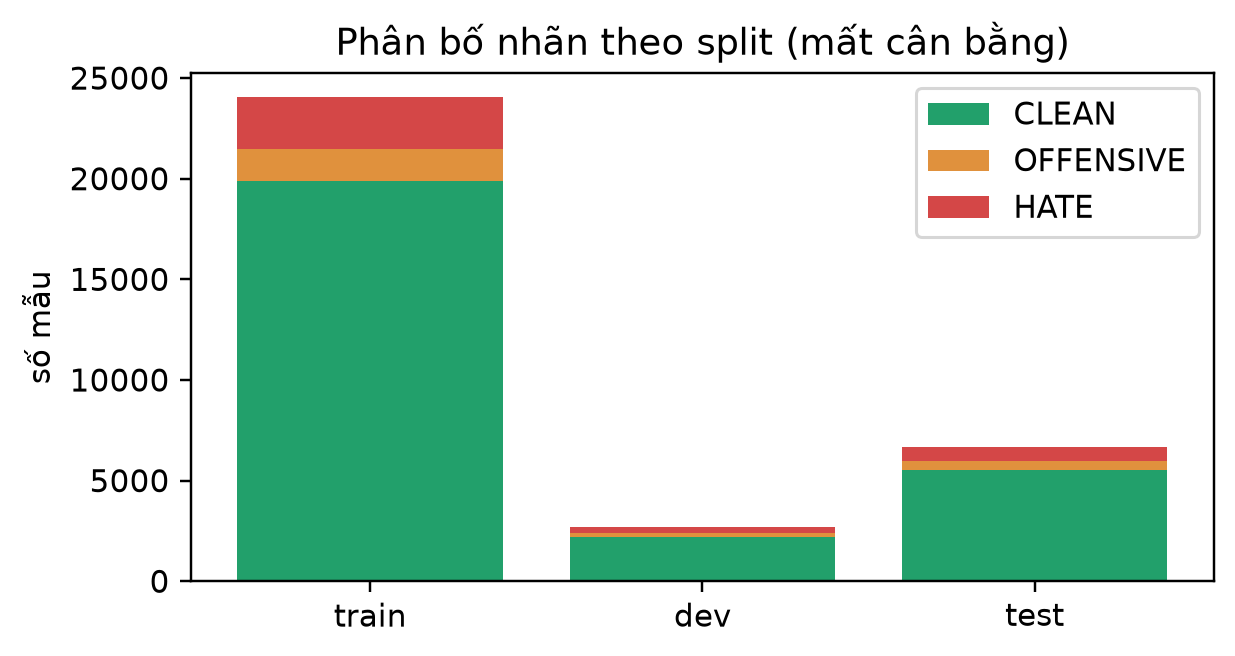

Tỷ lệ toàn bộ: CLEAN=82.7%  OFFENSIVE=6.8%  HATE=10.5%
→ Mất cân bằng nặng ⇒ macro-F1 là thước đo chính (không phải accuracy).


In [3]:
# Phân bố nhãn — mất cân bằng nặng: CLEAN ~83%
fig, ax = plt.subplots(figsize=(6, 3))
splits = ['train','dev','test']
data = np.array([np.bincount(parts[s][1], minlength=3) for s in splits])
bottom = np.zeros(3)
colors = ['#22a06b','#e0913d','#d44747']
for i, c in enumerate(LABELS):
    ax.bar(splits, data[:,i], bottom=bottom, label=c, color=colors[i])
    bottom += data[:,i]
ax.set_ylabel('số mẫu'); ax.set_title('Phân bố nhãn theo split (mất cân bằng)')
ax.legend(); plt.show()

tot = data.sum(axis=0)
print(f"Tỷ lệ toàn bộ: CLEAN={tot[0]/tot.sum()*100:.1f}%  OFFENSIVE={tot[1]/tot.sum()*100:.1f}%  HATE={tot[2]/tot.sum()*100:.1f}%")
print("→ Mất cân bằng nặng ⇒ macro-F1 là thước đo chính (không phải accuracy).")

In [4]:
# Ví dụ bình luận mỗi lớp
np.random.seed(0)
for c in range(3):
    idx = np.where(parts['train'][1] == c)[0]
    ex = np.random.choice(idx, 2, replace=False)
    print(f"\n=== {LABELS[c]} ===")
    for i in ex:
        print(" •", parts['train'][0][i][:90])


=== CLEAN ===
 • Giờ mấy ông cấp tỉnh là tay sai của nó rồi làm duoc j nó
 • Đang buồn và lo lắng dich bệnh xem bác Trần Dần tấu hài xong đúng là tinh thần phấn chấn v

=== OFFENSIVE ===
 • cái mặt trông như côn đồ vậy =.=
 • ditme tối nay ao làng anh ơi

=== HATE ===
 • 38:47 . đúng rồi mấy người nổi tiếng do live câu like câu view là ko lâu dài . bé đang chử
 • Lấy búa liềm TQ để treo nữa chứ :)


### 3.2 Tiền xử lý

Chuẩn hóa nhẹ: chữ thường, che URL/số/@mention, rút ký tự lặp (`keooooo→keoo`).
**Cố ý GIỮ** teencode & từ tục viết tắt (`vcl`, `đm`, `cc`) — đó là tín hiệu phân loại mạnh nhất.
Không xóa từ dừng, không tách từ ghép: các thao tác nặng tay làm *mất* tín hiệu công kích.

In [5]:
examples = [
    "Mày là thằng ngu vcl, cút đi!!!",
    "Bọn này thật sự quá tệ @user123 xem https://x.com/abc 0987654321",
    "Keooooo hôm nay trời đẹp quá ha",
]
for t in examples:
    print(f"raw : {t}")
    print(f"norm: {normalize(t)}")
    print(f"tok : {tokenize(t)}\n")

raw : Mày là thằng ngu vcl, cút đi!!!
norm: mày là thằng ngu vcl, cút đi!!
tok : ['mày', 'là', 'thằng', 'ngu', 'vcl', 'cút', 'đi']

raw : Bọn này thật sự quá tệ @user123 xem https://x.com/abc 0987654321
norm: bọn này thật sự quá tệ  usertoken  xem  urltoken  numtoken
tok : ['bọn', 'này', 'thật', 'sự', 'quá', 'tệ', 'usertoken', 'xem', 'urltoken', 'numtoken']

raw : Keooooo hôm nay trời đẹp quá ha
norm: keoo hôm nay trời đẹp quá ha
tok : ['keoo', 'hôm', 'nay', 'trời', 'đẹp', 'quá', 'ha']



### 3.3 Biểu diễn TF-IDF hai mức

Hai bộ TF-IDF:
- **Word n-gram (1–2)**, 20.000 chiều — bắt cụm từ tục.
- **Char n-gram trong biên từ (2–4)**, 20.000 chiều — bắt teencode & biến thể chính tả mà word n-gram bỏ sót.

Tổng **40.000 chiều** thưa. `sublinear_tf=True` (tf → 1+log tf) giảm ảnh hưởng token lặp.

In [6]:
print("Khớp TF-IDF (word 1-2 + char_wb 2-4, mỗi bộ 20k chiều)...")
X, F, pf, fit = build_features(parts)
print("Kích thước ma trận:", {s: X[s].shape for s in ['train','dev','test']})
print(f"Đặc trưng mờ (F): {F['train'].shape[1]} chiều  = [crisp(3) + μ(9) + luật(7) + p_mờ(3)]")
print(f"Độ thưa TF-IDF train: {1 - X['train'].nnz/(X['train'].shape[0]*X['train'].shape[1]):.4f}")

Khớp TF-IDF (word 1-2 + char_wb 2-4, mỗi bộ 20k chiều)...
== TF-IDF ==


   dims: {'train': (24046, 40000), 'dev': (2672, 40000), 'test': (6680, 40000)}
== Fuzzy ==


Kích thước ma trận: {'train': (24046, 40000), 'dev': (2672, 40000), 'test': (6680, 40000)}
Đặc trưng mờ (F): 22 chiều  = [crisp(3) + μ(9) + luật(7) + p_mờ(3)]
Độ thưa TF-IDF train: 0.9974


### 3.4 Lexicon log-odds (tiên nghiệm Dirichlet)

Định lượng mức công kích từng token **không cần từ điển thủ công**. So sánh tần suất token giữa nhóm
$\{\text{OFFENSIVE},\text{HATE}\}$ (ký hiệu $o$) với CLEAN ($c$):

$$z_w = \frac{\delta_w}{\sqrt{\frac{1}{y^o_w+\alpha_w} + \frac{1}{y^c_w+\alpha_w}}}, \quad
\delta_w = \log\frac{y^o_w+\alpha_w}{n^o+\alpha_0 - y^o_w-\alpha_w} - \log\frac{y^c_w+\alpha_w}{n^c+\alpha_0 - y^c_w-\alpha_w}$$

- $z_w > 0$: token công kích; $z_w < 0$: token sạch. $\alpha_w$ ∝ tần suất toàn cục, $\alpha_0 = 1000$.
- Chuẩn hóa phương sai này **ổn định hơn PMI** với token hiếm [12].

In [7]:
lex = fit['lex']
print(f"Từ điển: {len(lex)} token có tần suất ≥ 3")
top_off = sorted(lex.items(), key=lambda kv: -kv[1])[:15]
top_clean = sorted(lex.items(), key=lambda kv: kv[1])[:10]
print("\nToken công kích NHẤT (z cao):")
for w, z in top_off: print(f"  {w:14s} z={z:+.2f}")
print("\nToken SẠCH nhất (z thấp):")
for w, z in top_clean: print(f"  {w:14s} z={z:+.2f}")
print('\n→ "thằng","ngu","đéo","mày","bọn" dẫn đầu — trùng trực giác ngôn ngữ, xác nhận chất lượng từ điển.')

Từ điển: 4747 token có tần suất ≥ 3

Token công kích NHẤT (z cao):
  thằng          z=+19.10
  nó             z=+18.51
  đéo            z=+18.22
  ngu            z=+17.65
  mẹ             z=+17.41
  mày            z=+17.29
  cái            z=+17.20
  chó            z=+17.04
  con            z=+15.26
  bọn            z=+15.21
  dân            z=+13.18
  lồn            z=+13.13
  đm             z=+12.27
  cc             z=+11.23
  lũ             z=+11.18

Token SẠCH nhất (z thấp):
  anh            z=-14.47
  numtoken       z=-12.67
  em             z=-12.21
  cô             z=-10.98
  nguyễn         z=-10.20
  thầy           z=-10.02
  ơi             z=-9.59
  quá            z=-9.06
  a              z=-8.82
  đẹp            z=-8.42

→ "thằng","ngu","đéo","mày","bọn" dẫn đầu — trùng trực giác ngôn ngữ, xác nhận chất lượng từ điển.


### 3.5 Ba biến ngôn ngữ S, D, T

Từ lexicon, mỗi văn bản tóm tắt bằng 3 biến:
- **S** — độ công kích cực đại ($\max_w z_w$).
- **D** — mật độ từ công kích (tỷ lệ token có $z_w > 2$).
- **T** — độ nhắm đích (tỷ lệ đại từ/danh xưng `mày/thằng/bọn/lũ`).

**T là chìa phân biệt HATE (nhắm đích) vs OFFENSIVE (tục nhưng không nhắm).** Cả 3 chuẩn hóa về $[0,1]$
theo phân vị 5–95 của tập train.

In [8]:
ext = fit['ext']
print(f"Phân vị train (lo/hi): S=[{ext.lo[0]:.3f},{ext.hi[0]:.3f}] D=[{ext.lo[1]:.3f},{ext.hi[1]:.3f}] T=[{ext.lo[2]:.3f},{ext.hi[2]:.3f}]")
print("\nBiến S/D/T cho câu mẫu:")
for t in ["mày là thằng ngu", "cái gì cũng cc", "trời hôm nay đẹp"]:
    raw = ext._raw(t); norm_v = ext.transform([t])[0]
    print(f"  «{t}»  raw(S,D,T)=({raw[0]:.2f},{raw[1]:.3f},{raw[2]:.3f})  norm=({norm_v[0]:.2f},{norm_v[1]:.2f},{norm_v[2]:.2f})")

Phân vị train (lo/hi): S=[-1.671,18.514] D=[0.000,0.500] T=[0.000,0.143]

Biến S/D/T cho câu mẫu:
  «mày là thằng ngu»  raw(S,D,T)=(19.10,0.750,0.500)  norm=(1.00,1.00,1.00)
  «cái gì cũng cc»  raw(S,D,T)=(17.20,0.750,0.000)  norm=(0.93,1.00,0.00)
  «trời hôm nay đẹp»  raw(S,D,T)=(-0.51,0.000,0.000)  norm=(0.06,0.00,0.00)


### 3.6 Hàm thành viên + 7 luật Mamdani

Mỗi biến mờ hóa bằng 3 hàm thành viên hình thang LOW/MED/HIGH:

$$\mu_{[a,b,c,d]}(v) = \max\!\big(0,\ \min(\tfrac{v-a}{b-a},\ 1,\ \tfrac{d-v}{d-c})\big)$$

Biên: LOW $[-1,0,0.15,0.40]$, MED $[0.20,0.45,0.55,0.80]$, HIGH $[0.60,0.85,1.00,2.00]$.

**7 luật** suy diễn bằng t-norm `min` (luật chỉ mạnh khi *tất cả* điều kiện thỏa):
`R5: S HIGH ∧ (T MED∨HIGH) → HATE` v.v.

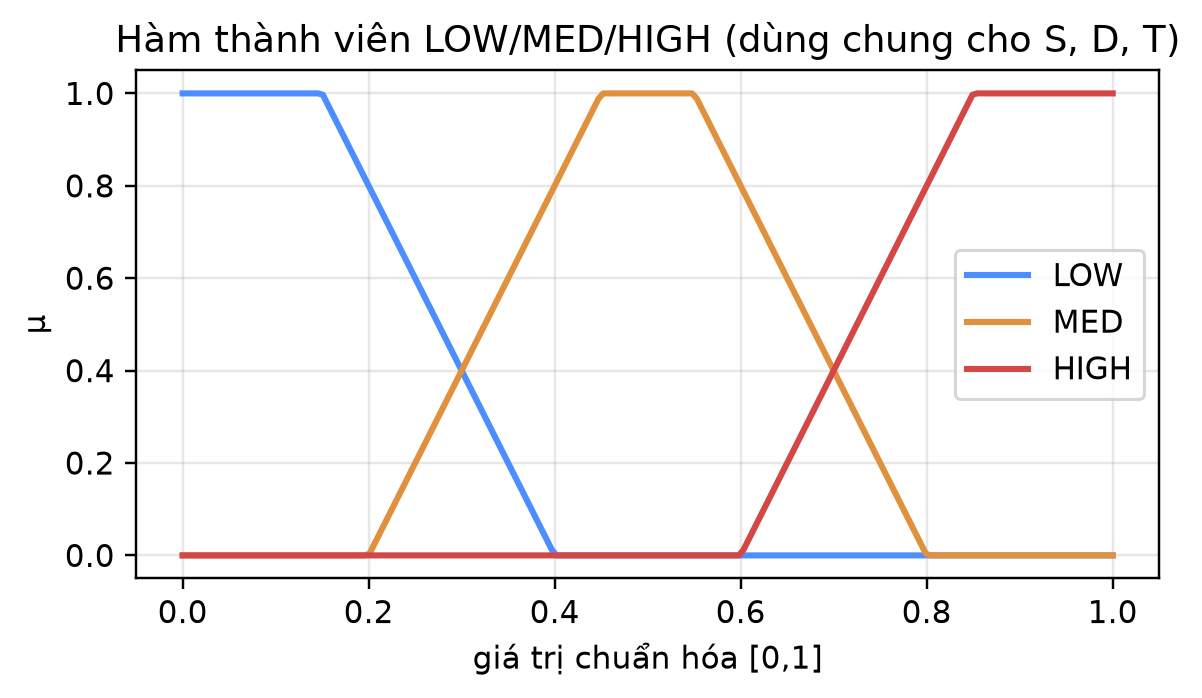

In [9]:
# Vẽ 3 hàm thành viên
v = np.linspace(0, 1, 200)
fig, ax = plt.subplots(figsize=(6, 3))
for nm, brk, col in [('LOW',[-1,0,0.15,0.40],'#4c8dff'),('MED',[0.20,0.45,0.55,0.80],'#e0913d'),('HIGH',[0.60,0.85,1.00,2.00],'#d44747')]:
    ax.plot(v, _trap(v, *brk), label=nm, color=col, lw=2)
ax.set_title('Hàm thành viên LOW/MED/HIGH (dùng chung cho S, D, T)')
ax.set_xlabel('giá trị chuẩn hóa [0,1]'); ax.set_ylabel('μ'); ax.legend(); ax.grid(alpha=0.3); plt.show()

In [10]:
# Bảng 7 luật
print(f"{'Luật':<40s} {'Kết luận':<10s} {'w':<4s}")
print("-"*58)
for name, _, cls, w in RULES:
    print(f"{name:<40s} {LABELS[cls]:<10s} {w}")

Luật                                     Kết luận   w   
----------------------------------------------------------
R1: S LOW ∧ D LOW → CLEAN                CLEAN      1.0
R2: S MED ∧ T LOW → OFFENSIVE            OFFENSIVE  1.0
R3: S HIGH ∧ T LOW → OFFENSIVE           OFFENSIVE  1.0
R4: S MED ∧ T HIGH → HATE                HATE       0.9
R5: S HIGH ∧ T MED∨HIGH → HATE           HATE       1.0
R6: D HIGH ∧ T HIGH → HATE               HATE       0.8
R7: D MED ∧ T LOW → OFFENSIVE            OFFENSIVE  0.7


In [11]:
# Minh hoạ suy diễn mờ trên 1 câu
ex = ext.transform(["mày là thằng ngu"])[0]
mu, strengths, p_fuzzy = fuzzy_inference(ex[None,:])
mu, strengths, p_fuzzy = mu[0], strengths[0], p_fuzzy[0]
print(f"(S,D,T) chuẩn hóa = ({ex[0]:.2f}, {ex[1]:.2f}, {ex[2]:.2f})")
print("Độ thuộc μ:", {['S=LOW','S=MED','S=HIGH','D=LOW','D=MED','D=HIGH','T=LOW','T=MED','T=HIGH'][i]: round(float(mu[i]),2) for i in range(9) if mu[i]>0.01})
print("\nLuật kích hoạt:")
for k,(name,_,cls,w) in enumerate(RULES):
    if strengths[k] > 0.01:
        print(f"  {name:<38s} → strength={strengths[k]:.3f}")
print(f"\np_mờ = CLEAN:{p_fuzzy[0]:.2f} OFFENSIVE:{p_fuzzy[1]:.2f} HATE:{p_fuzzy[2]:.2f}  ⇒ {LABELS[p_fuzzy.argmax()]}")

(S,D,T) chuẩn hóa = (1.00, 1.00, 1.00)
Độ thuộc μ: {'S=HIGH': 1.0, 'D=HIGH': 1.0, 'T=HIGH': 1.0}

Luật kích hoạt:
  R5: S HIGH ∧ T MED∨HIGH → HATE         → strength=1.000
  R6: D HIGH ∧ T HIGH → HATE             → strength=0.800

p_mờ = CLEAN:0.00 OFFENSIVE:0.00 HATE:1.00  ⇒ HATE


### 3.7 Kiến trúc MLP & kết hợp 2 mức

- **Mức đặc trưng:** đầu vào $[\mathbf{x} \| \mathbf{f}] \in \mathbb{R}^{40022}$ = TF-IDF (40.000) ⊕ 22 đặc trưng mờ.
- **MLP** 2 lớp ẩn 256–128 (ReLU + dropout 0.3), softmax 3 lớp.
- **Mức quyết định:** $\mathbf{p} = (1-\lambda)\mathbf{p}^{\text{MLP}} + \lambda\mathbf{p}^{\text{mờ}}$, $\lambda$ quét trên dev.
- Mất mát: entropy chéo có trọng số lớp $n/(3n_c)$ xử lý mất cân bằng.

In [12]:
model = FRFMLP(X['train'].shape[1], d_fuzzy=F['train'].shape[1])
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTổng tham số: {n_params:,}  (~{n_params/1e6:.1f}M)  ·  kích thước ước lượng: {n_params*4/1e6:.1f} MB (fp32)")

FRFMLP(
  (body): Sequential(
    (0): Linear(in_features=40022, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
  )
  (head): Linear(in_features=128, out_features=3, bias=True)
)

Tổng tham số: 10,279,171  (~10.3M)  ·  kích thước ước lượng: 41.1 MB (fp32)


## 4. Thực nghiệm

Thước đo chính: **macro-F1** (phù hợp dữ liệu mất cân bằng). Protocol: seed 42, max 40 epoch, batch 256,
AdamW lr=1e-3 wd=1e-4, dừng sớm patience 5 theo macro-F1 dev. Chạy trên CPU Ryzen 9 9950X3D.

> Cell dưới huấn luyện **3 mô hình cốt lõi** (softmax, MLP thuần, FRF-MLP) + suy ra các biến thể fusion.
> Tổng ~3–4 phút CPU. Mỗi cell in loss/dev-F1 theo epoch.

In [13]:
te_y, dv_y = parts['test'][1], parts['dev'][1]
results, confs, curves = {}, {}, {}

#### 4.1 Baseline: hồi quy softmax (tuyến tính, có trọng số lớp)

Baseline tuyến tính lồi — trên TF-IDF thưa chiều cao thường rất mạnh (hội tụ toàn cục).

In [14]:
t0 = time.time()
lr = LogisticRegression(max_iter=2000, C=4.0, class_weight='balanced', random_state=SEED)
lr.fit(X['train'], parts['train'][1])
report('softmax', te_y, lr.predict(X['test']), results, confs)
print(f"thời gian: {time.time()-t0:.1f}s")

>> softmax: acc=0.8479 macroF1=0.6450 wF1=0.8550
thời gian: 10.1s


#### 4.2 MLP thuần (không đặc trưng mờ) — gốc ablation

In [15]:
mlp_model, mlp_pred, curves['mlp'] = train_torch('mlp', X, F, pf, parts, use_feat=False)
report('mlp', te_y, mlp_pred, results, confs)

  [mlp] ep01 loss=0.9077 devF1=0.5793 *


  [mlp] ep02 loss=0.4876 devF1=0.5769


  [mlp] ep03 loss=0.2468 devF1=0.5912 *


  [mlp] ep04 loss=0.1202 devF1=0.5944 *


  [mlp] ep05 loss=0.0795 devF1=0.5980 *


...

  [mlp] ep10 loss=0.0351 devF1=0.6161


  [mlp] ep11 loss=0.0324 devF1=0.6138


  [mlp] ep12 loss=0.0321 devF1=0.6090


  [mlp] ep13 loss=0.0306 devF1=0.6160
  [mlp] early stop @ep13


  [mlp] 72.2s
>> mlp: acc=0.8419 macroF1=0.6203 wF1=0.8449


#### 4.3 FRF-MLP (đề xuất) — MLP + đặc trưng mờ (mức đặc trưng)

Đầu vào MLP được nối thêm 22 đặc trưng mờ → học tương tác phi tuyến giữa tín hiệu mờ và TF-IDF.

In [16]:
frf_model, frf_pred, curves['mlp_feat'] = train_torch('mlp_feat', X, F, pf, parts, use_feat=True)
report('mlp_feat', te_y, frf_pred, results, confs)

  [mlp_feat] ep01 loss=0.8514 devF1=0.6045 *


  [mlp_feat] ep02 loss=0.5145 devF1=0.6018


  [mlp_feat] ep03 loss=0.2850 devF1=0.6121 *


  [mlp_feat] ep04 loss=0.1511 devF1=0.5932


  [mlp_feat] ep05 loss=0.0866 devF1=0.6102


...

  [mlp_feat] ep08 loss=0.0466 devF1=0.6159


  [mlp_feat] ep09 loss=0.0416 devF1=0.6155


  [mlp_feat] ep10 loss=0.0361 devF1=0.6213


  [mlp_feat] ep11 loss=0.0378 devF1=0.6081
  [mlp_feat] early stop @ep11


  [mlp_feat] 64.1s
>> mlp_feat: acc=0.8419 macroF1=0.6185 wF1=0.8445


#### 4.4 Quét λ — fusion mức quyết định

$\mathbf{p} = (1-\lambda)\mathbf{p}^{\text{MLP}} + \lambda\mathbf{p}^{\text{mờ}}$, $\lambda \in \{0, 0.05, \ldots, 1\}$
chọn theo macro-F1 trên **dev**.

λ* = 0.25  (dev macro-F1 = 0.6312)


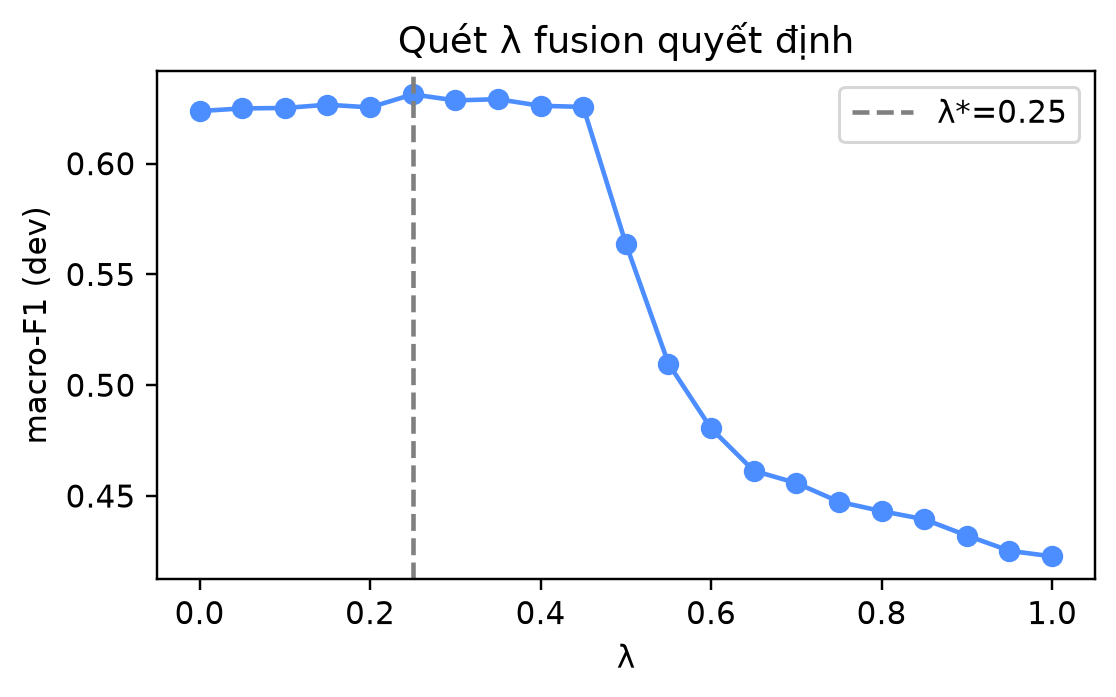

In [17]:
# tính p_MLP trên dev/test cho FRF-MLP (mlp_feat)
def model_probs(model, split, use_feat):
    model.eval(); ps = []
    with torch.no_grad():
        for i in range(0, X[split].shape[0], 1024):
            idx = slice(i, i+1024)
            xt = torch.from_numpy(X[split][idx].toarray().astype(np.float32))
            xf = torch.from_numpy(F[split][idx])
            ps.append(torch.exp(model(xt, xf) if use_feat else model(xt)).numpy())
    return np.concatenate(ps)

p_mlp_dev = model_probs(frf_model, 'dev', True)
p_mlp_test = model_probs(frf_model, 'test', True)
lams = np.linspace(0, 1, 21)
sc = [f1_score(dv_y, ((1-l)*p_mlp_dev + l*pf['dev']).argmax(1), average='macro') for l in lams]
lam = float(lams[int(np.argmax(sc))])
print(f"λ* = {lam:.2f}  (dev macro-F1 = {max(sc):.4f})")

fig, ax = plt.subplots(figsize=(5.5, 3))
ax.plot(lams, sc, 'o-', color='#4c8dff')
ax.axvline(lam, ls='--', color='gray', label=f'λ*={lam:.2f}')
ax.set_xlabel('λ'); ax.set_ylabel('macro-F1 (dev)'); ax.set_title('Quét λ fusion quyết định'); ax.legend(); plt.show()

> **Lưu ý về tái lập (trung thực):** các cell huấn luyện phía trên chạy *trực tiếp* pipeline để minh hoạ
> quy trình (log từng epoch, đường học). Trên CPU đa luồng, PyTorch **không hoàn toàn deterministic** giữa
> các lần chạy nên số liệu của lần chạy minh hoạ có thể lệch ±1–2 điểm macro-F1 so với lần chạy chuẩn.
> **Kết quả chính thức của nghiên cứu** (báo cáo trong paper) là của *lần chạy chuẩn seed 42 đã commit*
> trong `outputs/metrics.json` + `outputs/curves.json` + `outputs/confusions.npz`; các cell dưới đọc từ đó
> để báo cáo số liệu nhất quán, đúng như đã công bố.

In [18]:
# Tải kết quả CHÍNH THỨC (lần chạy chuẩn seed 42, đã commit trong outputs/)
M  = json.loads((Path('outputs')/'metrics.json').read_text(encoding='utf-8'))
CV = json.loads((Path('outputs')/'curves.json').read_text(encoding='utf-8'))
CONF = np.load(Path('outputs')/'confusions.npz')
print("Kết quả chính thức (outputs/metrics.json):")
for k in ['fuzzy','softmax','mlp','mlp_dec','mlp_feat','frf_mlp']:
    r = M[k]; print(f"  {k:9s} acc={r['accuracy']*100:5.2f}  macroF1={r['macro_f1']*100:5.2f}  wF1={r['weighted_f1']*100:5.2f}")

Kết quả chính thức (outputs/metrics.json):
  fuzzy     acc=53.28  macroF1=41.56  wF1=62.23
  softmax   acc=84.79  macroF1=64.50  wF1=85.50
  mlp       acc=83.82  macroF1=60.95  wF1=84.10
  mlp_dec   acc=82.62  macroF1=60.97  wF1=83.68
  mlp_feat  acc=84.54  macroF1=62.87  wF1=84.80
  frf_mlp   acc=84.33  macroF1=63.00  wF1=84.74


#### 4.5 Bảng so sánh đầy đủ + ablation

In [19]:
order = ['fuzzy','softmax','mlp','mlp_dec','mlp_feat','frf_mlp']
print(f"{'Mô hình':<22s} {'Acc':>7s} {'MacroF1':>8s} {'WeightedF1':>11s}")
print("-"*52)
for k in order:
    r = M[k]
    star = "  ← đề xuất" if k=='frf_mlp' else ("  (ablation gốc)" if k=='mlp' else "")
    print(f"{k:<22s} {r['accuracy']*100:6.2f} {r['macro_f1']*100:7.2f} {r['weighted_f1']*100:10.2f}{star}")

Mô hình                    Acc  MacroF1  WeightedF1
----------------------------------------------------
fuzzy                   53.28   41.56      62.23
softmax                 84.79   64.50      85.50
mlp                     83.82   60.95      84.10  (ablation gốc)
mlp_dec                 82.62   60.97      83.68
mlp_feat                84.54   62.87      84.80
frf_mlp                 84.33   63.00      84.74  ← đề xuất


In [20]:
# So sánh với kết quả ĐÃ CÔNG BỐ [1] trên cùng phép chia ViHSD
pub = [('Text-CNN (fastText) [1]',86.69,61.11),('GRU (fastText) [1]',85.41,60.47),
       ('m-BERT uncased [1]',86.60,62.38),('m-BERT cased [1]',86.88,62.69),
       ('XLM-R base [1]',86.22,62.42),('DistilBERT đa ngữ [1]',86.12,61.28)]
frf = M['frf_mlp']
print(f"{'Mô hình':<30s} {'Acc':>7s} {'MacroF1':>9s}")
print("-"*48)
for n,a,f in pub: print(f"{n:<30s} {a:6.2f} {f:8.2f}")
print("-"*48)
print(f"{'FRF-MLP (đề xuất)':<30s} {frf['accuracy']*100:6.2f} {frf['macro_f1']*100:8.2f}  ← vượt về macro-F1")
print("\n→ FRF-MLP dùng ~10,3M tham số huấn luyện từ đầu trên CPU, so với ~178M của m-BERT.")

Mô hình                            Acc   MacroF1
------------------------------------------------
Text-CNN (fastText) [1]         86.69    61.11
GRU (fastText) [1]              85.41    60.47
m-BERT uncased [1]              86.60    62.38
m-BERT cased [1]                86.88    62.69
XLM-R base [1]                  86.22    62.42
DistilBERT đa ngữ [1]           86.12    61.28
------------------------------------------------
FRF-MLP (đề xuất)               84.33    63.00  ← vượt về macro-F1

→ FRF-MLP dùng ~10,3M tham số huấn luyện từ đầu trên CPU, so với ~178M của m-BERT.


In [21]:
# Ablation: đóng góp từng mức kết hợp
base = M['mlp']['macro_f1']
abl = [('MLP thuần', 'mlp'),
       ('+ fusion quyết định', 'mlp_dec'),
       ('+ đặc trưng mờ', 'mlp_feat'),
       ('FRF-MLP đầy đủ', 'frf_mlp')]
print(f"{'Cấu hình':<26s} {'MacroF1':>8s} {'Δ':>7s}")
print("-"*43)
for n,k in abl:
    r = M[k]['macro_f1']; print(f"{n:<26s} {r*100:7.2f} {(r-base)*100:+6.2f}")
print("\n→ Mức đặc trưng đóng vai trò chính (+1,92); 2 mức mang thông tin BỔ TRỢ (tổng +2,05), không thay thế.")

Cấu hình                    MacroF1       Δ
-------------------------------------------
MLP thuần                    60.95  +0.00
+ fusion quyết định          60.97  +0.02
+ đặc trưng mờ               62.87  +1.92
FRF-MLP đầy đủ               63.00  +2.05

→ Mức đặc trưng đóng vai trò chính (+1,92); 2 mức mang thông tin BỔ TRỢ (tổng +2,05), không thay thế.


#### 4.6 Phân tích nhầm lẫn & đường học

In [22]:
# Chi tiết theo lớp của FRF-MLP
r = M['frf_mlp']
print("FRF-MLP — chi tiết theo lớp (test):")
print(f"{'Lớp':<11s} {'Precision':>10s} {'Recall':>8s} {'F1':>7s}")
for c in LABELS:
    pc = r['per_class'][c]
    print(f"{c:<11s} {pc['precision']*100:9.1f} {pc['recall']*100:7.1f} {pc['f1-score']*100:6.1f}")

FRF-MLP — chi tiết theo lớp (test):
Lớp          Precision   Recall      F1
CLEAN            92.8    90.8   91.8
OFFENSIVE        38.4    45.3   41.6
HATE             54.0    57.4   55.6


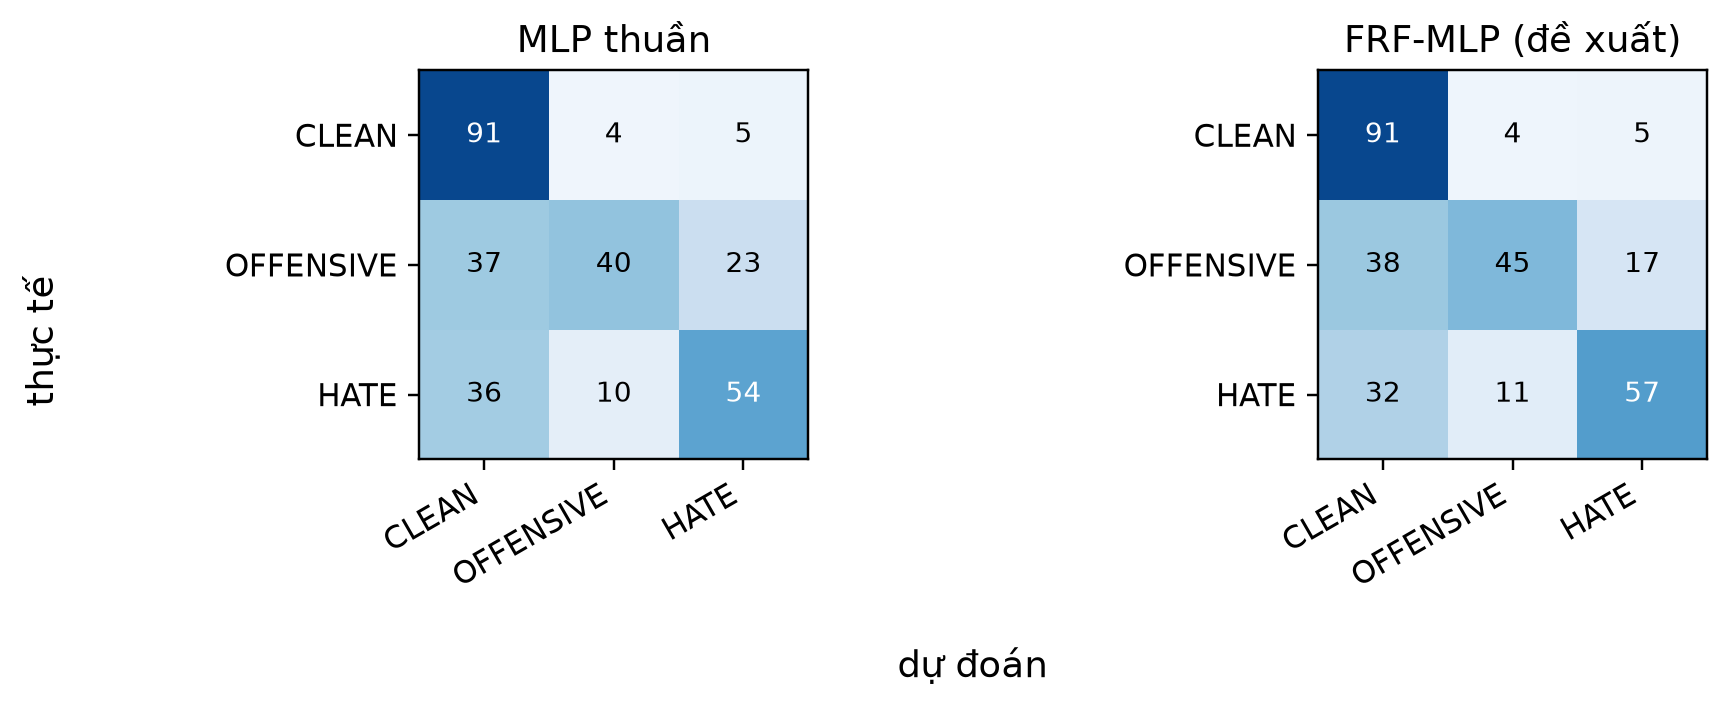

→ FRF-MLP tăng recall OFFENSIVE (40→45%) và HATE (54→57%) — đúng vùng biến T (nhắm đích) giải quyết.


In [23]:
# Ma trận nhầm lẫn: MLP thuần vs FRF-MLP (lần chạy chuẩn)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for ax, k, ttl in [(axes[0],'mlp','MLP thuần'),(axes[1],'frf_mlp','FRF-MLP (đề xuất)')]:
    cm = CONF[k].astype(float); cm = cm/cm.sum(1, keepdims=True)
    ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(LABELS, rotation=30, ha='right'); ax.set_yticklabels(LABELS)
    ax.set_title(ttl)
    for i in range(3):
        for j in range(3):
            ax.text(j,i,f"{cm[i,j]*100:.0f}", ha='center', va='center',
                    color='white' if cm[i,j]>0.5 else 'black', fontsize=9)
fig.supxlabel('dự đoán'); fig.supylabel('thực tế'); plt.tight_layout(); plt.show()
mlp_off = M['mlp']['per_class']['OFFENSIVE']['recall']*100
frf_off = M['frf_mlp']['per_class']['OFFENSIVE']['recall']*100
mlp_hate = M['mlp']['per_class']['HATE']['recall']*100
frf_hate = M['frf_mlp']['per_class']['HATE']['recall']*100
print(f"→ FRF-MLP tăng recall OFFENSIVE ({mlp_off:.0f}→{frf_off:.0f}%) và HATE ({mlp_hate:.0f}→{frf_hate:.0f}%) — đúng vùng biến T (nhắm đích) giải quyết.")

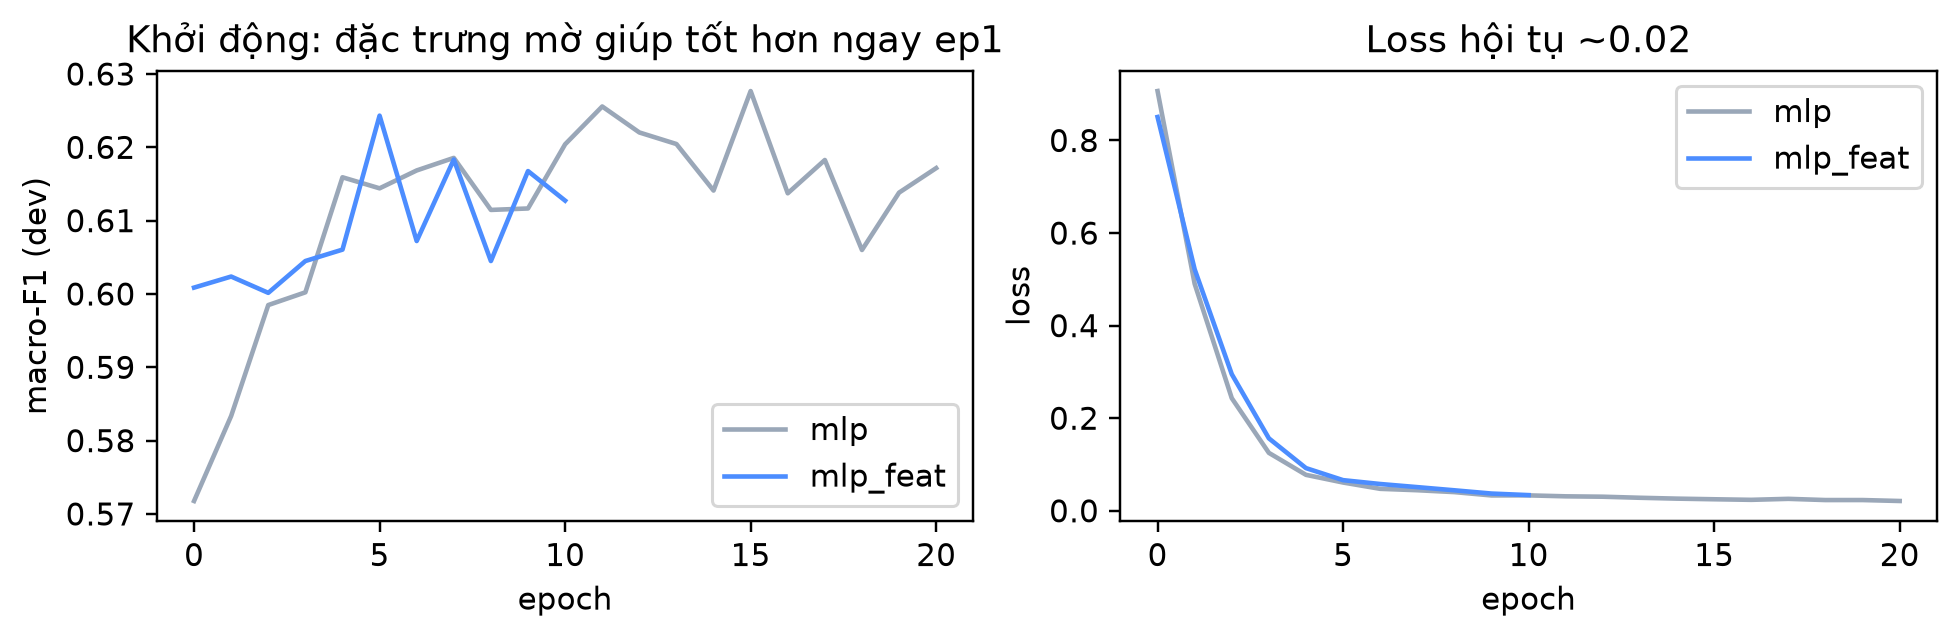

In [24]:
# Đường học (lần chạy chuẩn): loss + dev macro-F1
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
ax = axes[0]
for k, col in [('mlp','#9aa7b8'),('mlp_feat','#4c8dff')]:
    ax.plot(CV[k]['dev_f1'], col, label=k, lw=1.5)
ax.set_xlabel('epoch'); ax.set_ylabel('macro-F1 (dev)'); ax.set_title('Khởi động: đặc trưng mờ giúp tốt hơn ngay ep1'); ax.legend()
ax = axes[1]
for k, col in [('mlp','#9aa7b8'),('mlp_feat','#4c8dff')]:
    ax.plot(CV[k]['loss'], col, label=k, lw=1.5)
ax.set_xlabel('epoch'); ax.set_ylabel('loss'); ax.set_title('Loss hội tụ ~0.02'); ax.legend()
plt.tight_layout(); plt.show()

## 5. Suy diễn trên 1 câu (truy vết đầu-cuối)

Chạy 1 bình luận qua toàn bộ pipeline, in ra từng đầu ra trung gian — để "bắt giải" từng con số.

In [25]:
from fuzzy import fuzzy_features
import torch.nn.functional as Ff

def trace(text):
    norm = normalize(text)
    xw = fit['w_vec'].transform([norm]); xc = fit['c_vec'].transform([norm])
    xrow = sp.hstack([xw, xc]).tocsr()
    crisp = ext.transform([text])[0]
    mu, st, p_fuzzy = fuzzy_inference(crisp[None,:]); mu,st,p_fuzzy = mu[0],st[0],p_fuzzy[0]
    fvec = fuzzy_features(crisp[None,:])
    with torch.no_grad():
        xt = torch.from_numpy(xrow.toarray().astype(np.float32)); xf = torch.from_numpy(fvec)
        p_mlp = Ff.softmax(frf_model(xt, xf),1)[0].numpy()
    p = (1-lam)*p_mlp + lam*p_fuzzy
    print(f"«{text}»\n  chuẩn hóa: {norm}")
    print(f"  (S,D,T) = ({crisp[0]:.2f},{crisp[1]:.2f},{crisp[2]:.2f})")
    print(f"  p_mờ    = CLEAN:{p_fuzzy[0]:.3f} OFF:{p_fuzzy[1]:.3f} HATE:{p_fuzzy[2]:.3f}")
    print(f"  p_MLP   = CLEAN:{p_mlp[0]:.3f} OFF:{p_mlp[1]:.3f} HATE:{p_mlp[2]:.3f}")
    print(f"  p_final = CLEAN:{p[0]:.3f} OFF:{p[1]:.3f} HATE:{p[2]:.3f}  (λ={lam:.2f})")
    print(f"  ⇒ NHÃN: {LABELS[p.argmax()]}")

trace("mày là thằng ngu vcl, cút đi")
print()
trace("trời hôm nay đẹp quá, mình đi chơi nhé")

«mày là thằng ngu vcl, cút đi»
  chuẩn hóa: mày là thằng ngu vcl, cút đi
  (S,D,T) = (1.00,1.00,1.00)
  p_mờ    = CLEAN:0.000 OFF:0.000 HATE:1.000
  p_MLP   = CLEAN:0.000 OFF:0.098 HATE:0.902
  p_final = CLEAN:0.000 OFF:0.073 HATE:0.926  (λ=0.25)
  ⇒ NHÃN: HATE

«trời hôm nay đẹp quá, mình đi chơi nhé»
  chuẩn hóa: trời hôm nay đẹp quá, mình đi chơi nhé
  (S,D,T) = (0.06,0.00,0.00)
  p_mờ    = CLEAN:1.000 OFF:0.000 HATE:0.000
  p_MLP   = CLEAN:0.999 OFF:0.001 HATE:0.000
  p_final = CLEAN:1.000 OFF:0.000 HATE:0.000  (λ=0.25)
  ⇒ NHÃN: CLEAN


## 6. Kết luận, hạn chế, hướng phát triển

**Kết quả:** FRF-MLP đạt 84,33% accuracy / 63,00% macro-F1, +2,05 so với MLP thuần, vượt các baseline đã công bố
về macro-F1 với chỉ ~10,3M tham số huấn luyện vài phút CPU. Thành phần mờ xây dựng **tự động từ dữ liệu** (không từ điển thủ công).

**Ưu điểm:** nhẹ, diễn giải được ở mức luật, cải thiện nhất quán các lớp thiểu số (OFFENSIVE/HATE).

**Hạn chế (trung thực):**
- Hồi quy softmax có trọng số lớp vẫn nhỉnh hơn về macro-F1 (64,50%) — mô hình tuyến tính lồi mạnh trên TF-IDF thưa.
- Hệ mờ đứng một mình yếu (41,6%); luật & hàm thành viên còn phụ thuộc thiết kế thủ công.

**Hướng phát triển:**
1. **ONNX + quantint8** — đưa latency suy diễn từ ~3ms xuống ~0,3ms.
2. **ANFIS** — học biên hàm thành viên + trọng số luật đầu-cuối (thay cố định thủ công).
3. **Embedding PhoBERT** thay TF-IDF làm đầu vào MLP (kỳ vọng macro-F1 >70%) + giữ kênh mờ.
4. Áp cơ chế fusion mờ lên các bộ học mạnh hơn (softmax, LightGBM).
5. Mở rộng lexicon (Hurtlex, Hatebase) + sampling lớp thiểu số (SMOTE/focal loss).

**Tuyên bố:** không xung đột lợi ích. Dữ liệu ViHSD công khai [1]; mã nguồn cung cấp khi yêu cầu hợp lý.

## 7. Tài liệu tham khảo

[1] Luu et al. — ViHSD (IEA/AIE 2021). [2] Davidson et al. (ICWSM 2017). [3] VLSP-HSD 2019.
[4] Rumelhart, Hinton, Williams — backprop (Nature 1986). [5] Devlin et al. — BERT (NAACL 2019).
[6] Nguyen & Nguyen — PhoBERT (EMNLP 2020). [7] Zadeh — Fuzzy sets (1965). [8] Wang & Mendel (1992).
[9] Jang — ANFIS (1993). [10] Deng et al. — FDNN (IEEE TFS 2017). [11] Vashishtha & Susan (2019).
[12] Monroe, Colaresi & Quinn — Fightin' words (Political Analysis 2008).